In [1]:
import os
from itertools import combinations
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, gaussian_kde
import pickle
from matplotlib import rcParams, cycler
from matplotlib.cm import ScalarMappable
import cmasher as cmr
import sys
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc11 import *

In [2]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [3]:
def reduce_angle(x, y, axis = 1):
    dp = np.sum(x * y, axis = 1)
    xlen = np.sqrt(np.sum(x**2, axis = 1))
    ylen = np.sqrt(np.sum(y**2, axis = 1))
    ang = np.arccos(np.clip((dp/(xlen*ylen)), -1,1))
    return dp, ang

In [4]:
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

In [5]:
v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_scores = pd.read_pickle(os.path.join('c:\\',*os.getcwd().split('\\')[1:-1], v1_xs_file))
#v1_scores = pd.read_pickle(os.path.join('/',*os.getcwd().split('/')[:-1], v1_xs_file))
v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)

In [6]:
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [7]:
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01, 0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

In [8]:
optimized_model_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'permutation_test_free.pkl')
with open(optimized_model_file, 'rb') as f:
    optimized_model = pickle.load(f)

In [9]:
model = SGCCircuit(param_bounds, identify=False)

In [10]:
model.load_saved_parameters(optimized_model['final_epoch_params'])

In [11]:
loss_decay = optimized_model['loss_decay']
last_epoch = loss_decay[-1]
lsi = np.argsort(last_epoch)
best = np.where(last_epoch == last_epoch.min())[0][0]
print(f"Index of best parameters: {best}, loss = {last_epoch[best]}")

Index of best parameters: 305, loss = 0.06591796875


In [12]:
from itertools import combinations
from scipy import stats

In [13]:
def pairwise_vector_comp(population_resp, sfs, diff='abs'):
    sf_combos = list(combinations(sfs, 2)) # list of comparisons of each unique SF condition
    sf_combo_idx = np.array(list(combinations(np.arange(len(sfs)),2))) # index wise comparisons of the SF conditions
    sf_octave_diff = np.array([np.log2(x[1]/x[0]) for x in sf_combos]) # octave difference of each SF comparison
    sf_abs_diff = np.array([np.abs(x[1]-x[0]) for x in sf_combos]) # octave difference of each SF comparison

    switch = {
        'oct': sf_octave_diff,
        'abs': sf_abs_diff
    }
    sf_diff_idx = np.argsort(switch[diff]) # combo index sorted from lowest to highest octave difference

    dotprod, ang = reduce_angle(
        population_resp[:,:,sf_combo_idx[:,0],:],
        population_resp[:,:,sf_combo_idx[:,1],:]
    )
    labels = switch[diff][sf_diff_idx]
    return ang[:,sf_diff_idx], dotprod[:,sf_diff_idx], labels

def calculate_sign_sum(X, unit_ax = 1):
    ## Calculate enhancement and suppression sums over time
    exc = np.sum(np.clip(X, 0, None), axis = unit_ax)
    sum = np.sum(np.clip(X, None, 0), axis = unit_ax)
                
    return exc, sum

def calculate_esi(exc, sup):
    return (
        (exc - np.abs(sup))
        / (np.abs(sup) + exc)
    ) 

def calculate_desi(esi, sfs, diff = 'abs', return_average = True):
    sf_combos = list(combinations(sfs, 2)) # list of comparisons of each unique SF condition
    sf_combo_idx = np.array(list(combinations(np.arange(len(sfs)),2))) # index wise comparisons of the SF conditions
    sf_octave_diff = np.array([np.log2(x[1]/x[0]) for x in sf_combos]) # octave difference of each SF comparison
    sf_abs_diff = np.array([np.abs(x[1]-x[0]) for x in sf_combos]) # octave difference of each SF comparison

    switch = {
        'oct': sf_octave_diff,
        'abs': sf_abs_diff
    }
    sf_diff_idx = np.argsort(switch[diff]) # combo index sorted from lowest to highest octave difference
    
    desi = np.abs(
        (esi[:,sf_combo_idx[:,0],:]
         -esi[:,sf_combo_idx[:,1],:])
    )
    
    return desi[:,sf_diff_idx,:]

In [14]:
R = model.predict(X).numpy()

In [15]:
ang, dp, labels = pairwise_vector_comp(R,X)
exc, sup = calculate_sign_sum(R)
esi = calculate_esi(exc, sup)
desi = calculate_desi(esi, X)

In [16]:
condition_labels = [
    'Suppression(On) + CTF(On)',
    'Suppression(Off) + CTF(On)',
    'Suppression(On) + CTF(Off)',
    'Suppression(Off) + CTF(Off)',
]

conditions = [
    ['V1', np.arange(model.n_sample), [None], [0,1], 'inh_w', 0],
    ['dLGN', np.arange(model.n_sample), [0,1,2], [0,1], 'fts', 0],
    [['V1', np.arange(model.n_sample), [None], [0,1], 'inh_w', 0],
    ['dLGN', np.arange(model.n_sample), [0,1,2], [0,1], 'fts', 0],]
]

data = [
    {
        'cond': condition_labels[0],
        'resp': R,
        'orderlabel': labels,
        'ang': ang,
        'dp': dp,
        'exc': exc,
        'sup': sup,
        'esi': esi,
        'desi': desi
    }
]

for i, cond in enumerate(conditions):
    if len(cond) == 2:
        [model.set_parameter(*c) for c in cond]
    else:
        model.set_parameter(*cond)
        
    R = model.predict(X).numpy()
    ang, dp, labels = pairwise_vector_comp(R,X)
    exc, sup = calculate_sign_sum(R)
    esi = calculate_esi(exc, sup)
    desi = calculate_desi(esi, X)
    data.append(
        {
            'cond': condition_labels[i+1],
            'resp': R,
            'orderlabel': labels,
            'ang': ang,
            'dp': dp,
            'exc': exc,
            'sup': sup,
            'esi': esi,
            'desi': desi
        }
    )
    model = SGCCircuit(param_bounds, identify=False)
    model.load_saved_parameters(optimized_model['final_epoch_params'])

C:\Users\Sturdy\AppData\Local\Temp\ipykernel_59112\1312398805.py:5: RuntimeWarning: divide by zero encountered in divide
  ang = np.arccos(np.clip((dp/(xlen*ylen)), -1,1))
C:\Users\Sturdy\AppData\Local\Temp\ipykernel_59112\1312398805.py:5: RuntimeWarning: invalid value encountered in divide
  ang = np.arccos(np.clip((dp/(xlen*ylen)), -1,1))


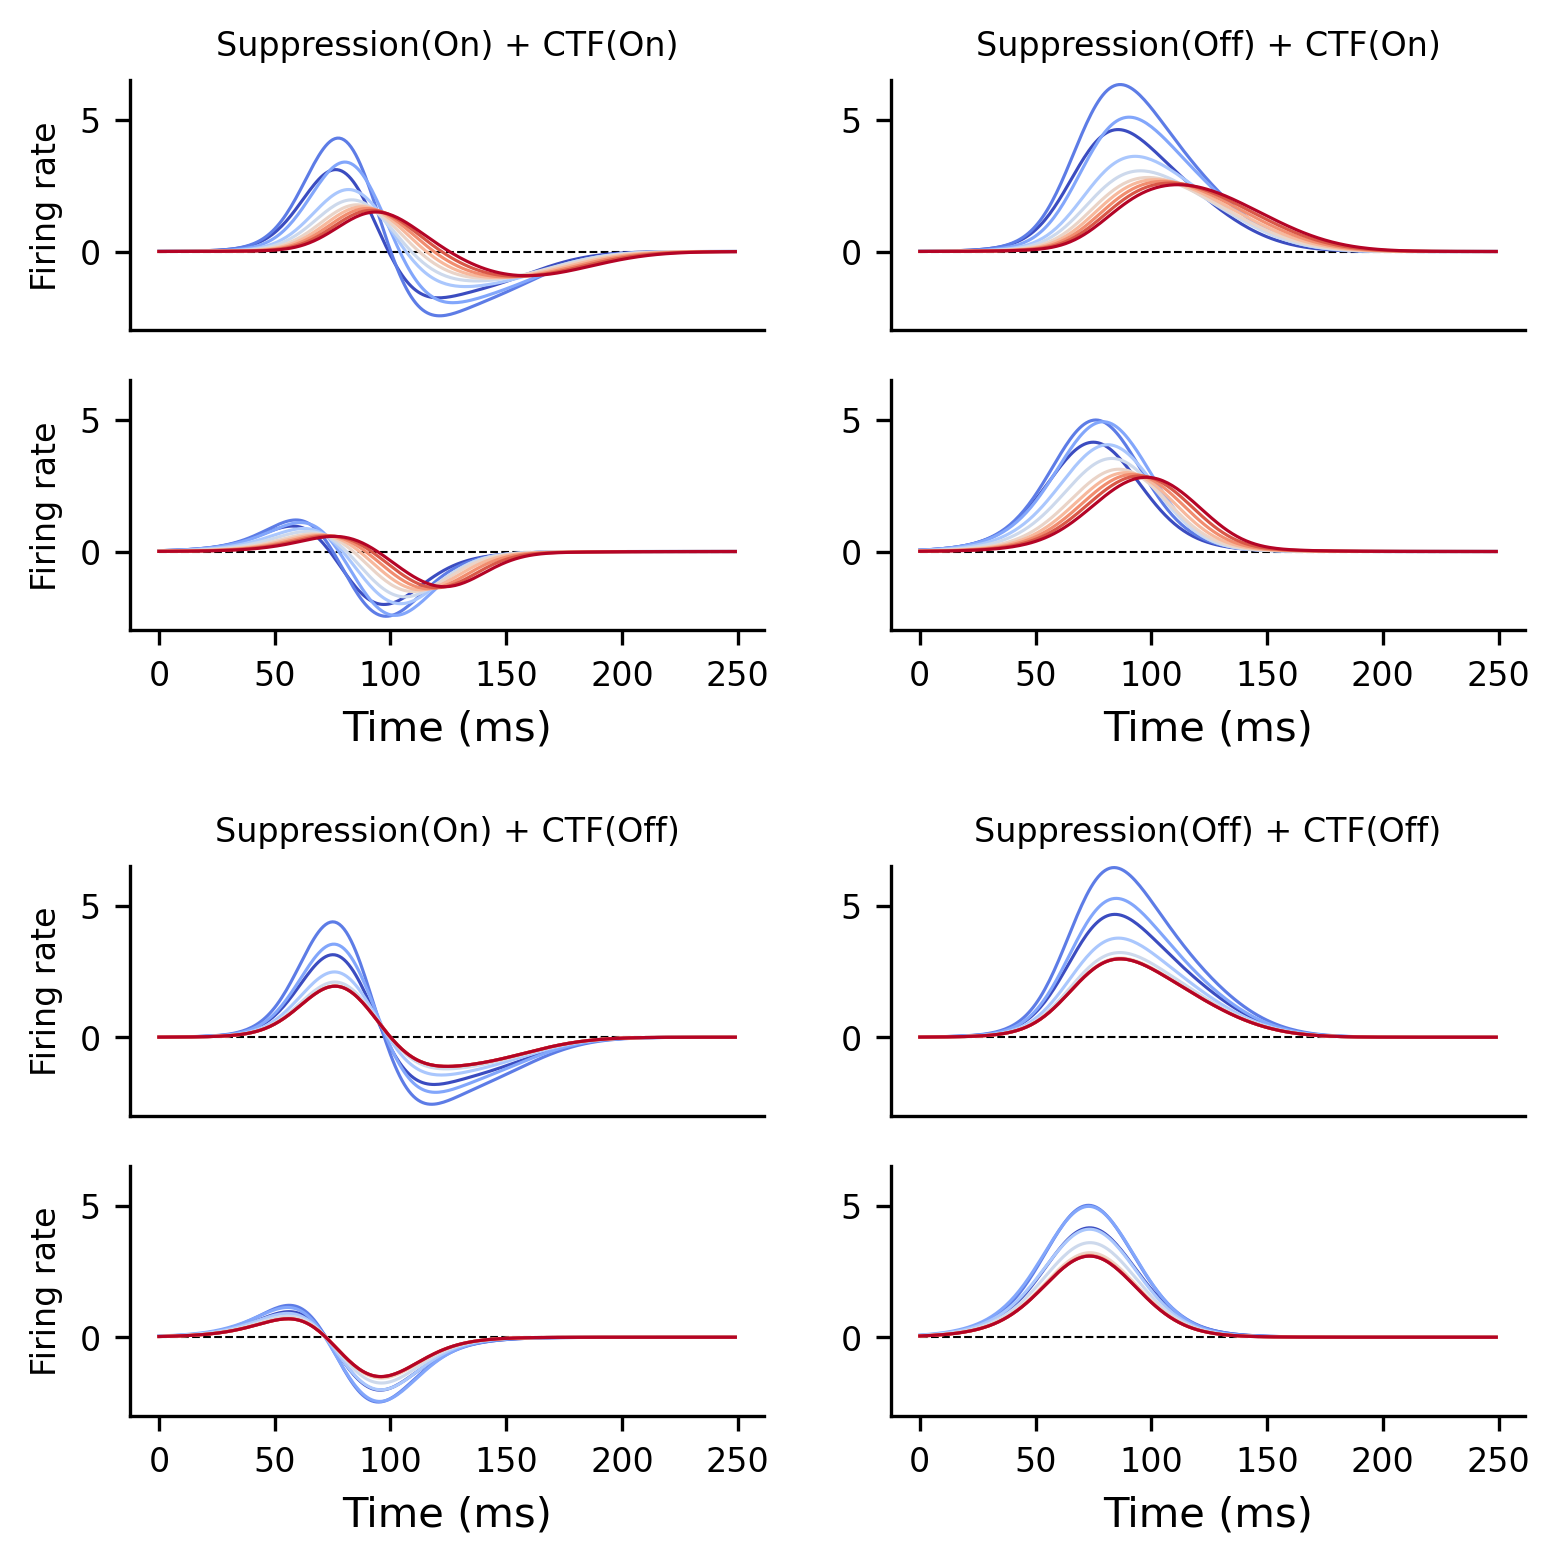

In [ ]:
cmap = plt.get_cmap('coolwarm') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig = plt.figure(figsize = (6,5))

# Split the figure into top and bottom subfigures with a gap between them
(sf_top, sf_bot) = fig.subfigures(2, 1, hspace=0.1)  # hspace controls the gap

ax_top = sf_top.subplots(2, 2)
ax_bot = sf_bot.subplots(2, 2)

for ax in [ax_top, ax_bot]:
    for row in range(2):
        ax[row, 0].set_ylabel("Firing rate", fontsize = 8)
        for col in range(2):
            ax[row,col].plot(np.zeros(250), '--', color = 'black', linewidth = linewidth)
            ax[row,col].tick_params(labelsize = fontsize)
            ax[row,col].spines['top'].set_visible(False)
            ax[row,col].spines['right'].set_visible(False)
            ax[row,col].set_ylim(-3,6.5)
            ax[row,col].set_ylim(-3,6.5)

i=0
row = 0
for col in range(2):
    r = data[i]['resp'].mean(0)
    ax_top[row, col].plot(r[0].T, linewidth = 0.75)
    ax_top[row, col].set_title(, fontsize = 8)
    ax_top[row, col].set_xticks([])
    ax_top[row+1, col].plot(r[1].T, linewidth = 0.75)
    ax_top[row+1, col].set_xlabel("Time (ms)")

    i+=1
row = 0
for col in range(2):
    r = data[i]['resp'].mean(0)
    ax_bot[row, col].plot(r[0].T, linewidth = 0.75)
    ax_bot[row, col].set_title(data[i]['cond'], fontsize = 8)
    ax_bot[row, col].set_xticks([])
    ax_bot[row+1, col].plot(r[1].T, linewidth = 0.75)
    ax_bot[row+1, col].set_xlabel("Time (ms)")
    i+=1


# Adjust internal spacing within each group independently
sf_top.subplots_adjust(hspace=0.2)
sf_bot.subplots_adjust(hspace=0.2)

# figname = 'ablation_analysis_conditions.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [51]:
(data[i]['dp']/data[i]['dp'].max((1,2))[:,None,None]).shape

(4000, 45, 250)

In [69]:
np.append(np.arange(0, 120, 30), np.arange(120, 210, 30)-180)

array([  0,  30,  60,  90, -60, -30,   0])

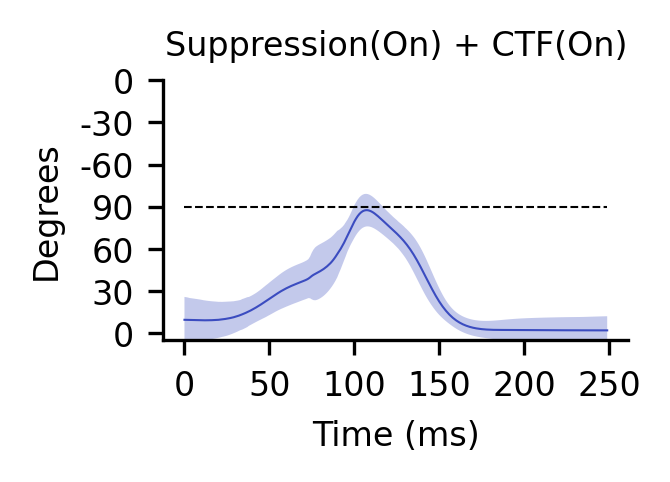

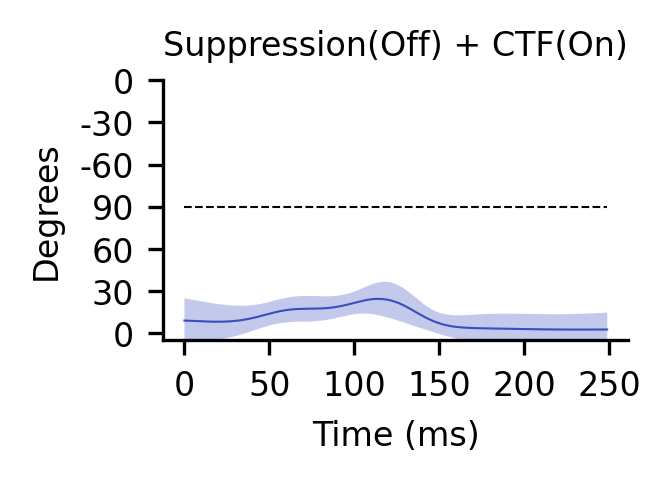

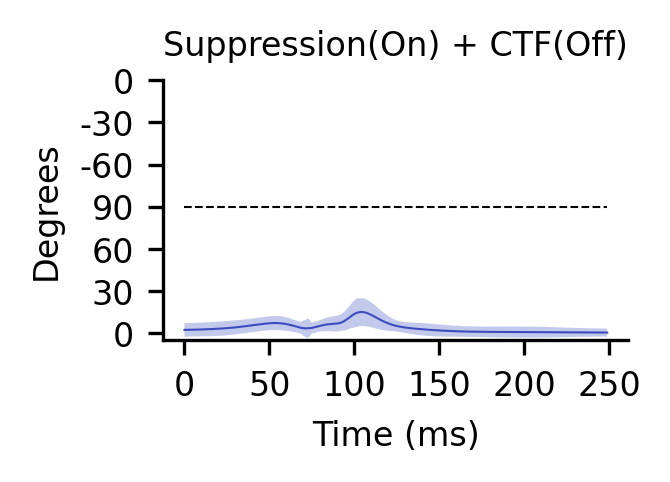

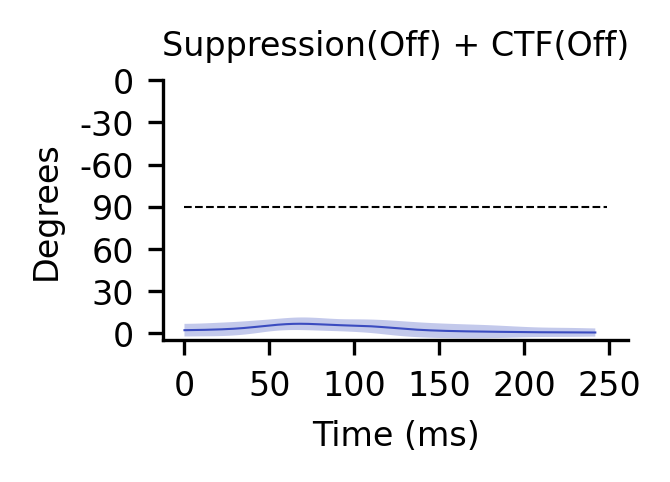

In [86]:
for i in range(4):
    fig, ax = plt.subplots(1, figsize = (2,1.125))

    ax.tick_params(labelsize = fontsize)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    

    ax.set_ylim(-5,180)
    ax.set_yticks(np.arange(0,210,30))
    ax.set_yticklabels(np.append(np.arange(0, 120, 30), np.arange(-60, 30, 30)))
    ax.plot(np.arange(250), [90]*250, '--', color = 'black', linewidth = linewidth)
    ax.plot(np.degrees(data[i]['ang'].mean(0)[-1]), linewidth = linewidth)
    ax.fill_between(
        np.arange(250),
        np.degrees(data[i]['ang'].mean(0)[-1]) + np.degrees(data[i]['ang'].std(0)[-1]),
        np.degrees(data[i]['ang'].mean(0)[-1]) - np.degrees(data[i]['ang'].std(0)[-1]),
        np.degrees(data[i]['ang'].mean(0)[-1]), alpha = 0.3
    )
    ax.set_title(data[i]['cond'], fontsize = fontsize)
    ax.set_xticks(np.arange(0,300,50))
    ax.set_ylabel("Degrees", fontsize = fontsize)
    ax.set_xlabel("Time (ms)", fontsize = fontsize)
    figname = f'ablation_analysis_angsep_v_dESI_{data[i]["cond"]}.svg'
    savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
    plt.savefig(savepath, transparent = False, facecolor = 'white',
            bbox_inches = 'tight', dpi = 300)


In [75]:
for cond in data:
    cond_label = cond['cond']
    esi = cond['esi']
    exc, sup = cond['exc'], cond['sup']


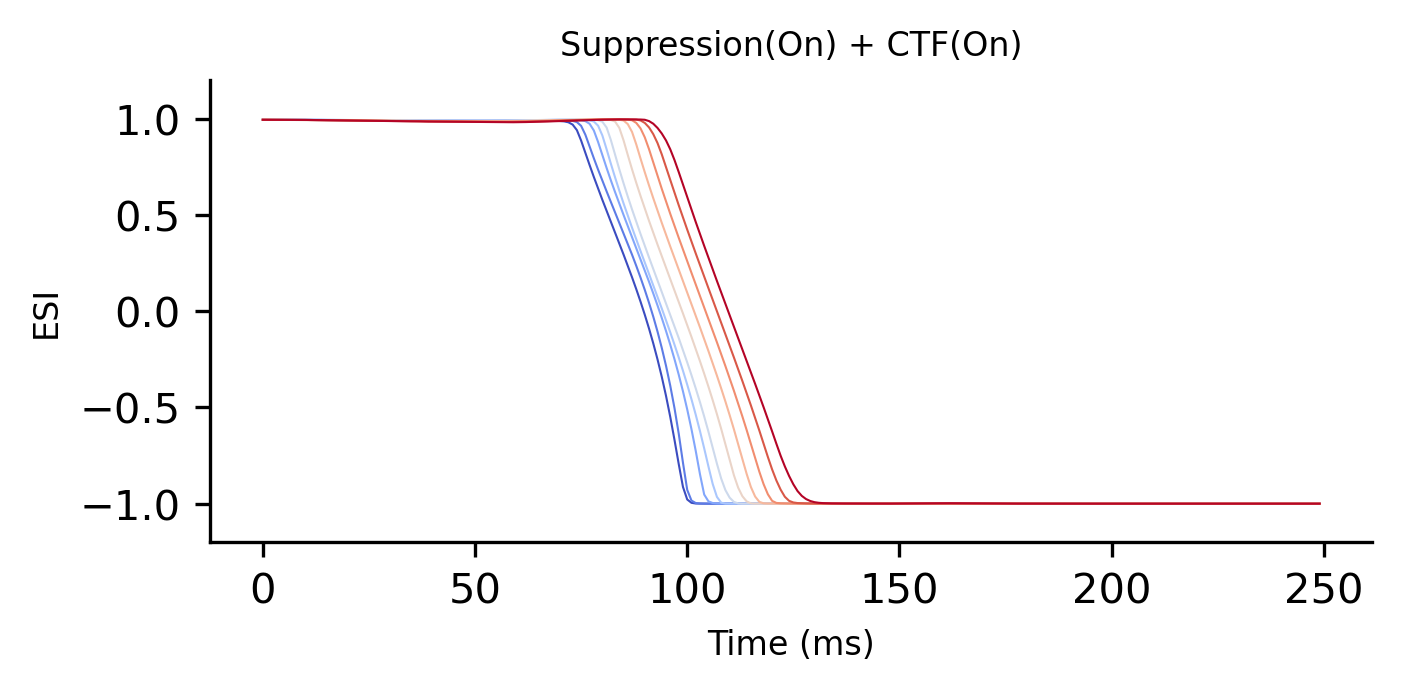

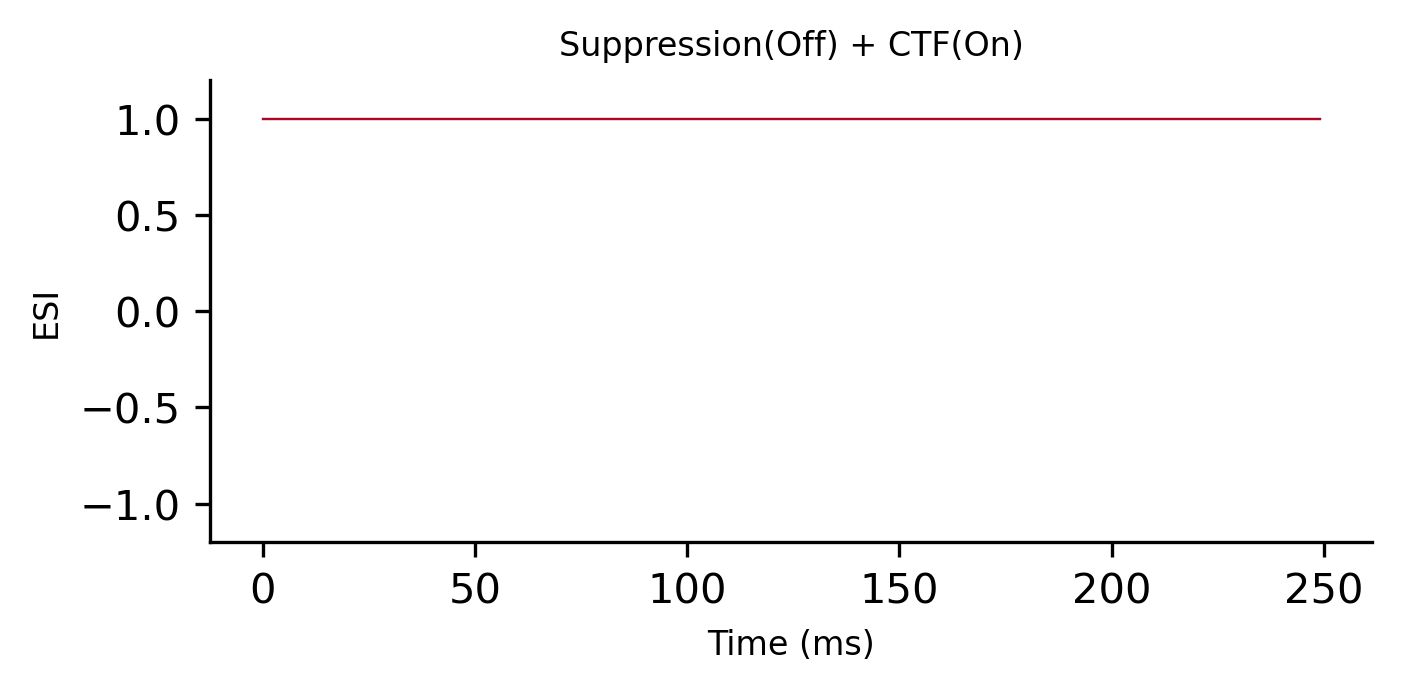

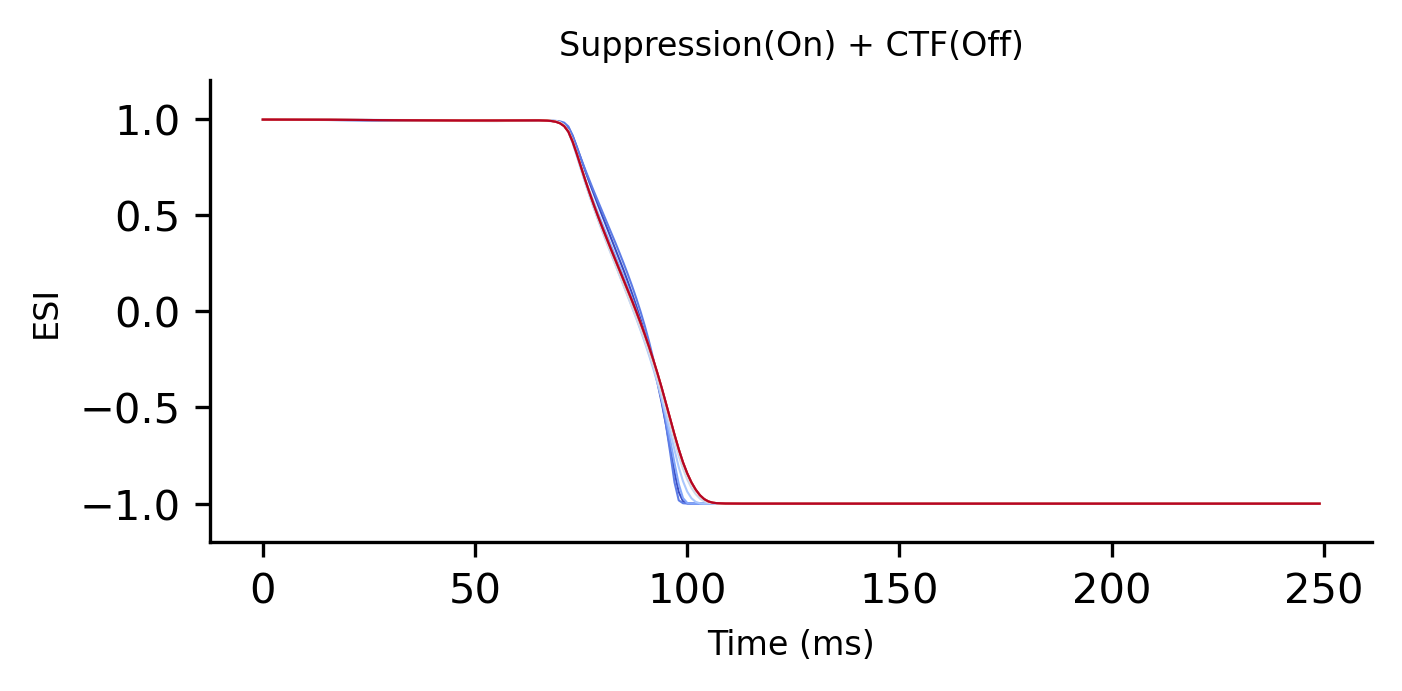

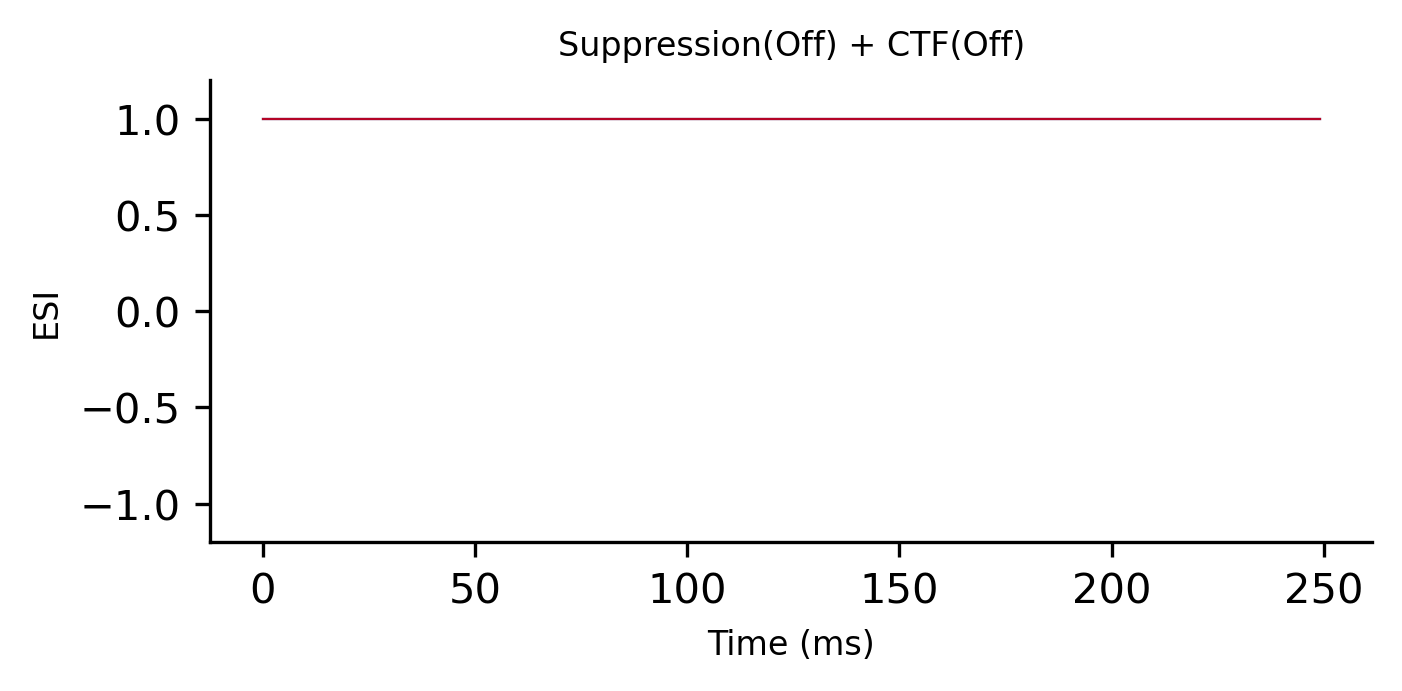

In [ ]:
for cond in data:
    cond_label = cond['cond']
    esi = cond['esi']
    exc, sup = cond['exc'], cond['sup']

    fongsize = 6
    cmap = plt.get_cmap('coolwarm') 
    rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
    fig, ax = plt.subplots(figsize = (5,2))
    ax.plot(esi.mean(0).T, linewidth = linewidth)
    ax.set_ylabel("ESI", fontsize = fontsize)
    ax.set_xlabel("Time (ms)", fontsize = fontsize)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(-1.2,1.2)
    ax.set_title(cond_label, fontsize = 8)

    # ax2 = fig.add_axes([0.2, 0.4, 0.15, 0.2])
    # ax2.plot(exc.mean(0)[:,:5].T, linewidth = linewidth)
    # ax2.set_title('ENH (first 5ms)', fontsize = fontsize)
    # ax3 = fig.add_axes([0.675, 0.4, 0.15, 0.2])
    # ax3.plot(sup.mean(0)[:,-5:].T, linewidth = linewidth)
    # ax3.set_title('SUP (last 5ms)', fontsize = fontsize)

    # for ax in [ax2, ax3]:
    #     ax.tick_params(labelsize = 5, rotation = 0)
    #     #ax.set_ylim(-0.0017,0.0017)
    #     ax.plot(np.zeros(5), '--', color = 'black', linewidth = linewidth)
    #     ax.spines['top'].set_visible(False)
    #     ax.spines['right'].set_visible(False)

    # figname = f'ablation_analysis_ESI_progression_{cond_label}.svg'
    # savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
    # plt.savefig(savepath, transparent = False, facecolor = 'white',
    #         bbox_inches = 'tight', dpi = 300)

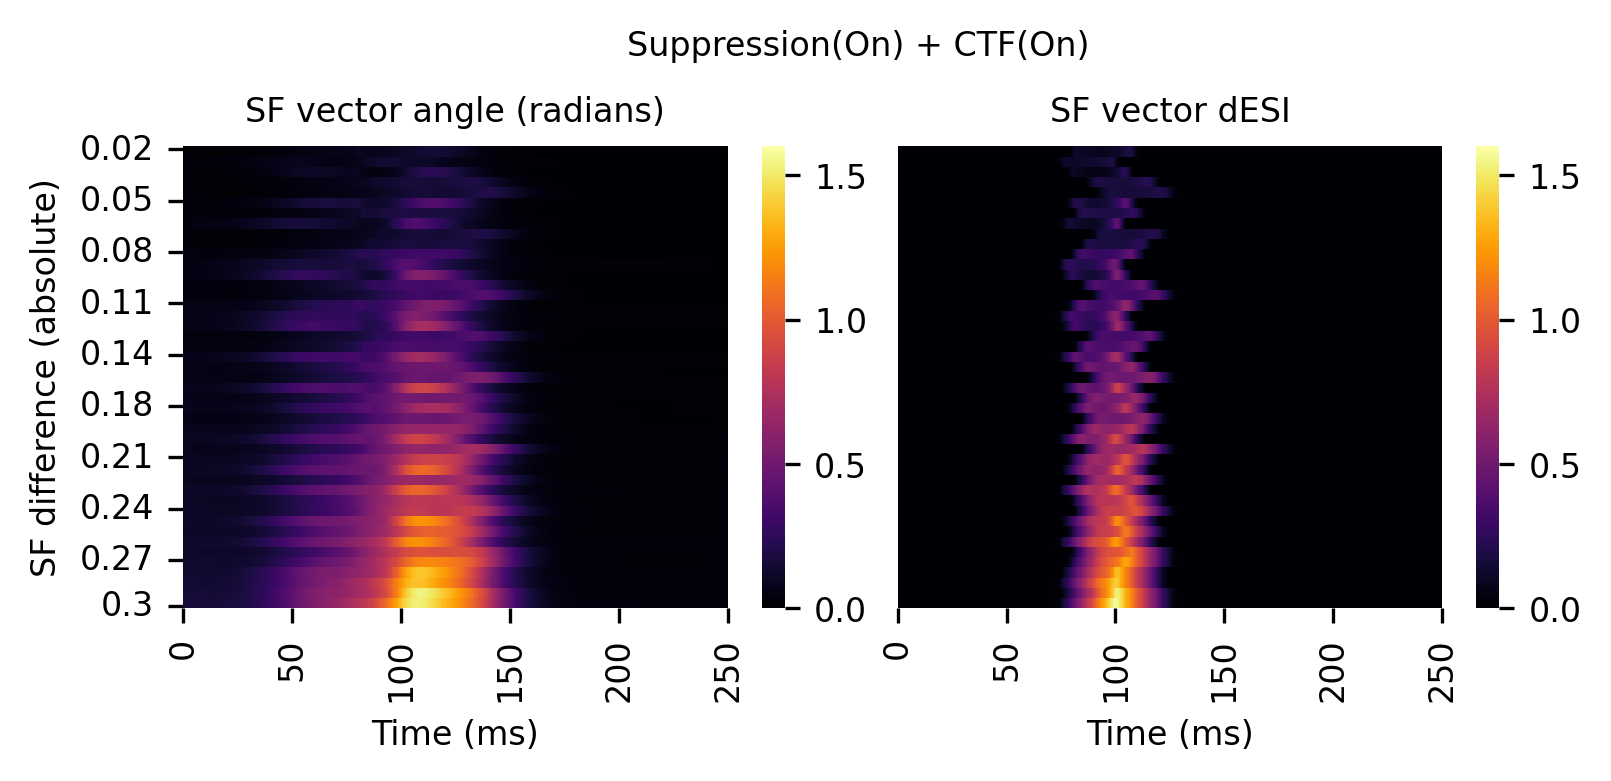

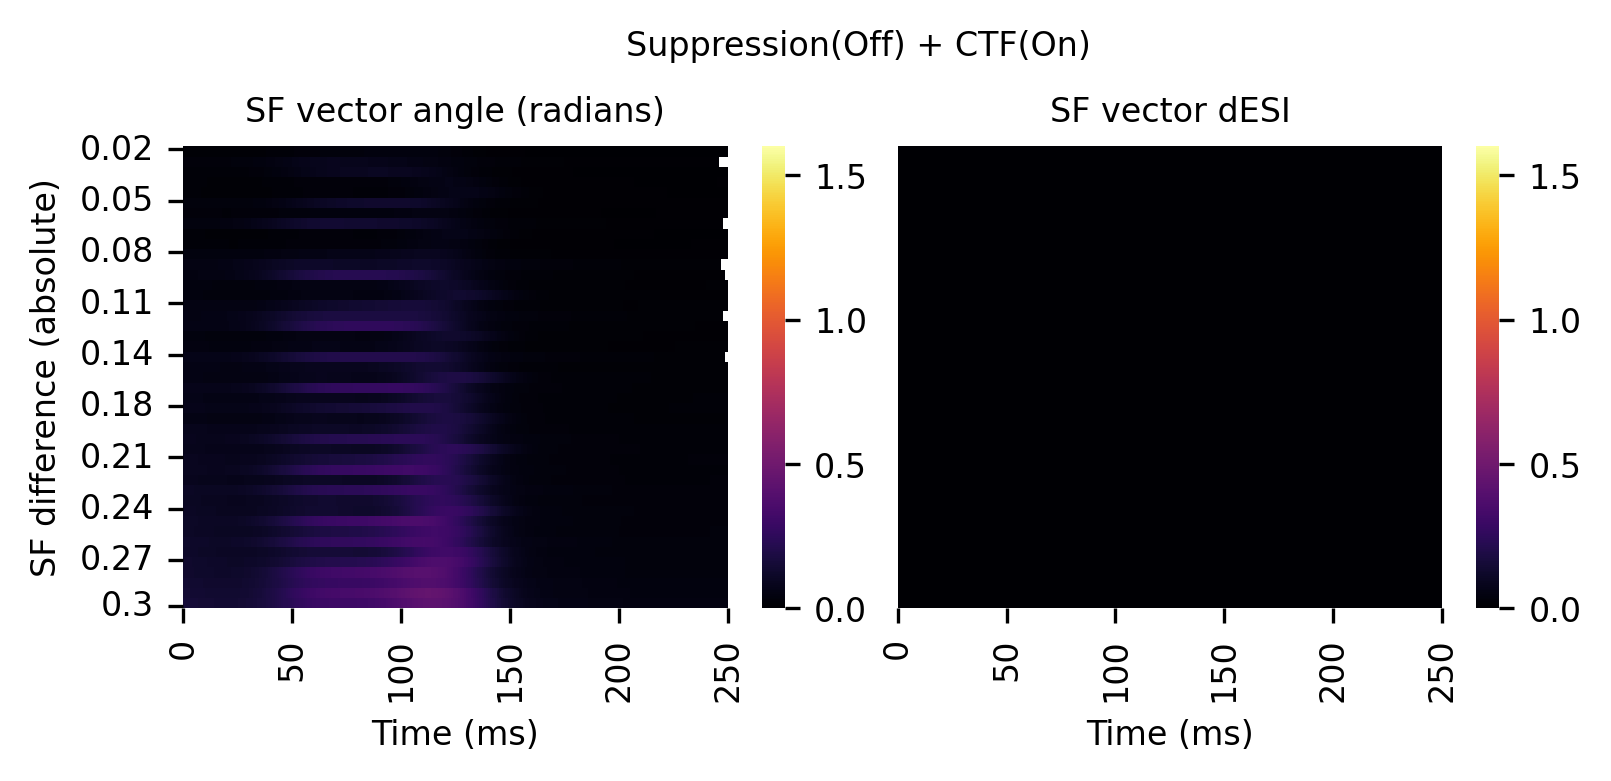

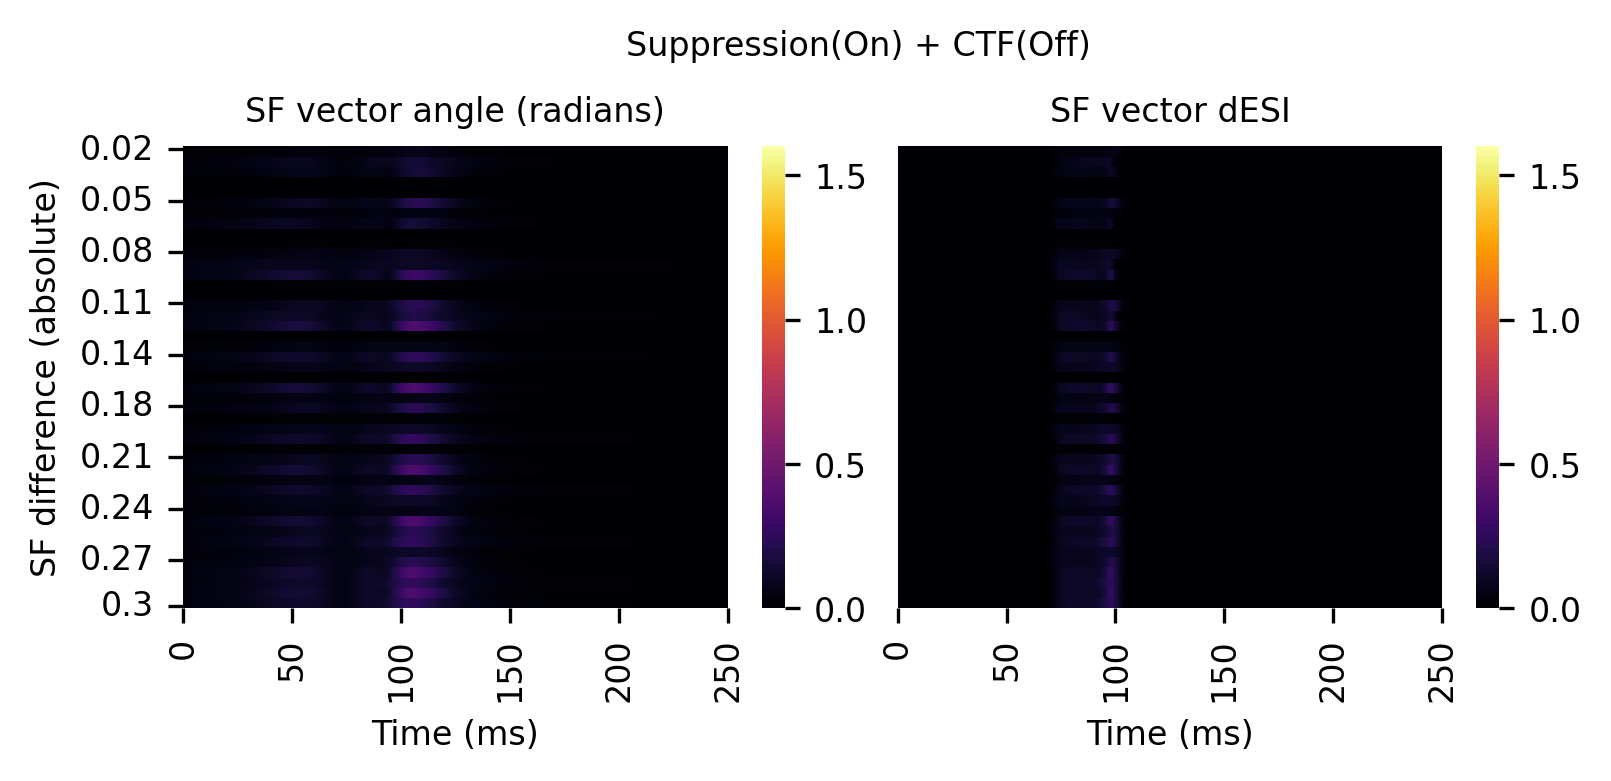

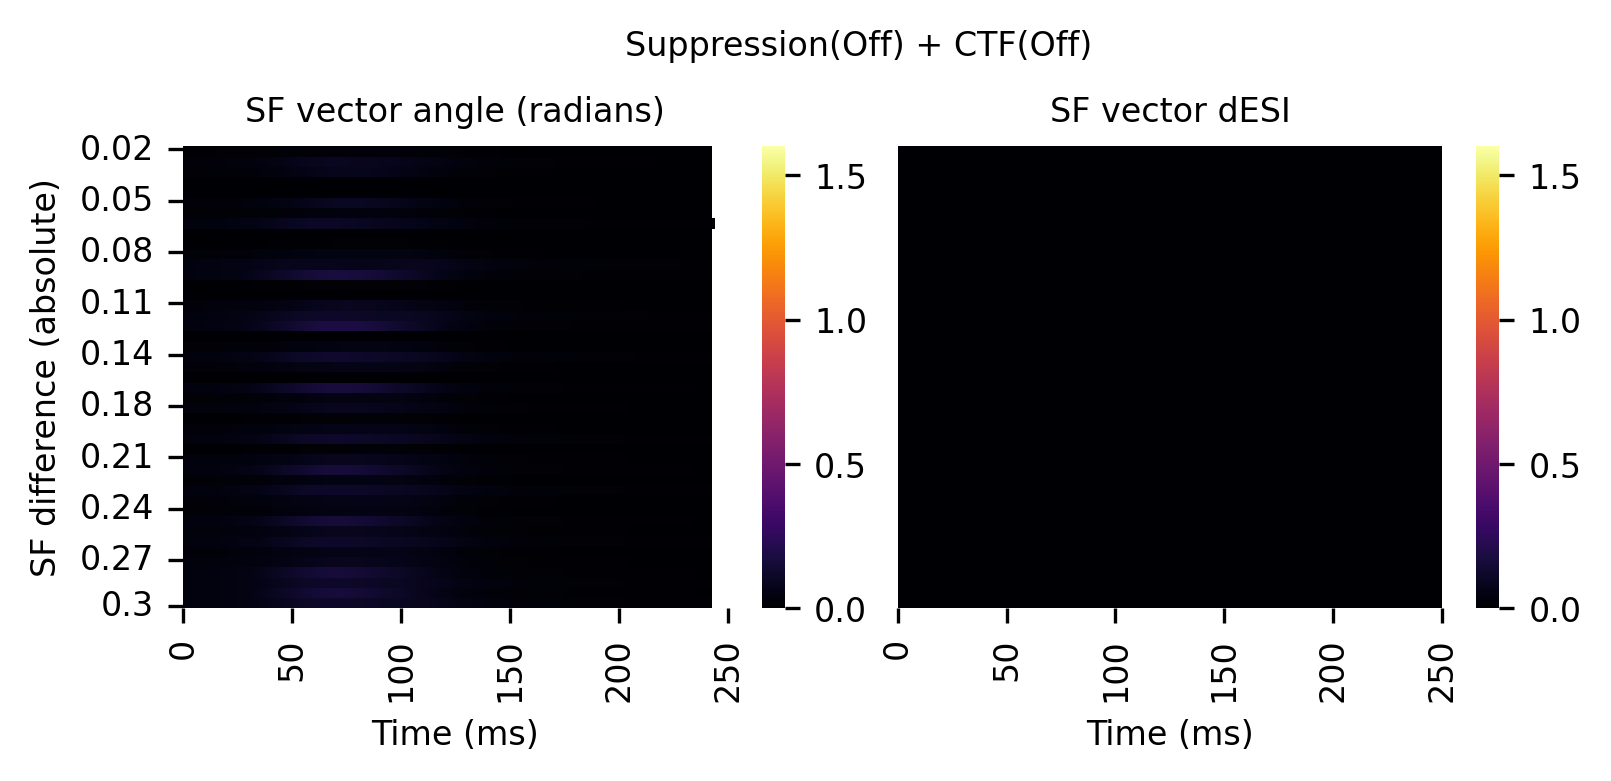

In [ ]:
for cond in data:
    cond_label = cond['cond']
    ang, desi = cond['ang'], cond['desi']

    fig, ax = plt.subplots(1,2, figsize = (6, 2))

    cmap = 'inferno'
    sns.heatmap(
        ang.mean(0), ax = ax[0], 
        cmap = cmap, vmin = 0, vmax = 1.6
    )
    sns.heatmap(
        desi.mean(0), ax = ax[1], 
        cmap = cmap, vmin = 0, vmax = 1.6
    )

    for i in range(2):
        ax[i].set_xlabel("Time (ms)", fontsize = fontsize)
        ax[i].tick_params(labelsize = fontsize)
        ax[i].spines['top'].set_visible(False)
        ax[i].spines['right'].set_visible(False)
        ax[i].set_xticks(np.arange(0,300,50))
        ax[i].set_xticklabels(np.arange(0,300,50))
        ax[i].collections[0].colorbar.ax.tick_params(labelsize = fontsize)

    plt.subplots_adjust(wspace = 0.05)
    ticks = np.arange(0.3,45.5,5)
    ticks[-1]-=0.5
    ax[0].set_yticks(ticks)
    ax[0].set_yticklabels(np.linspace(labels[0], labels[-1], 10).round(2))
    ax[0].set_ylabel("SF difference (absolute)", fontsize = fontsize)
    ax[1].set_yticks([])
    ax[0].set_title("SF vector angle (radians)", fontsize = fontsize)
    ax[1].set_title("SF vector dESI", fontsize = fontsize)
    fig.suptitle(cond_label, fontsize = 8, y = 1.075)

    # figname = f'ablation_analysis_angsep_v_dESI_{cond_label}.svg'
    # savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
    # plt.savefig(savepath, transparent = False, facecolor = 'white',
    #         bbox_inches = 'tight', dpi = 300)

C:\Users\Sturdy\AppData\Local\Temp\ipykernel_14008\3052836379.py:37: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr = np.round(np.nanmean([pearsonr(np.squeeze(desi[n,:,dmax]), ang[n,:,t1])[0] for n in range(4000)]), 2)
C:\Users\Sturdy\AppData\Local\Temp\ipykernel_14008\3052836379.py:37: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr = np.round(np.nanmean([pearsonr(np.squeeze(desi[n,:,dmax]), ang[n,:,t1])[0] for n in range(4000)]), 2)
C:\Users\Sturdy\AppData\Local\Temp\ipykernel_14008\3052836379.py:37: RuntimeWarning: Mean of empty slice
  pr = np.round(np.nanmean([pearsonr(np.squeeze(desi[n,:,dmax]), ang[n,:,t1])[0] for n in range(4000)]), 2)
C:\Users\Sturdy\AppData\Local\Temp\ipykernel_14008\3052836379.py:37: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr = np.round(np.nanmean([pearsonr(np.squeeze(desi[n,:,dmax]), ang[n,:,t1])[0] f

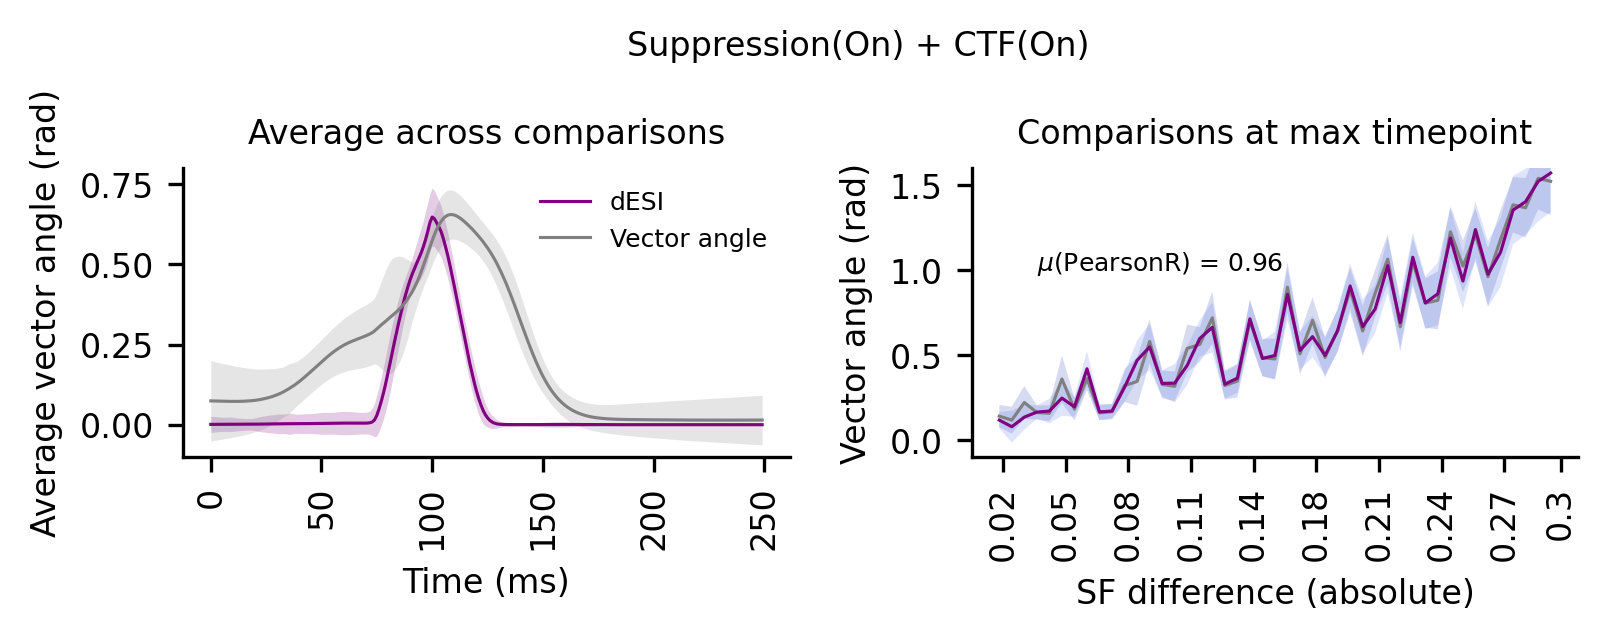

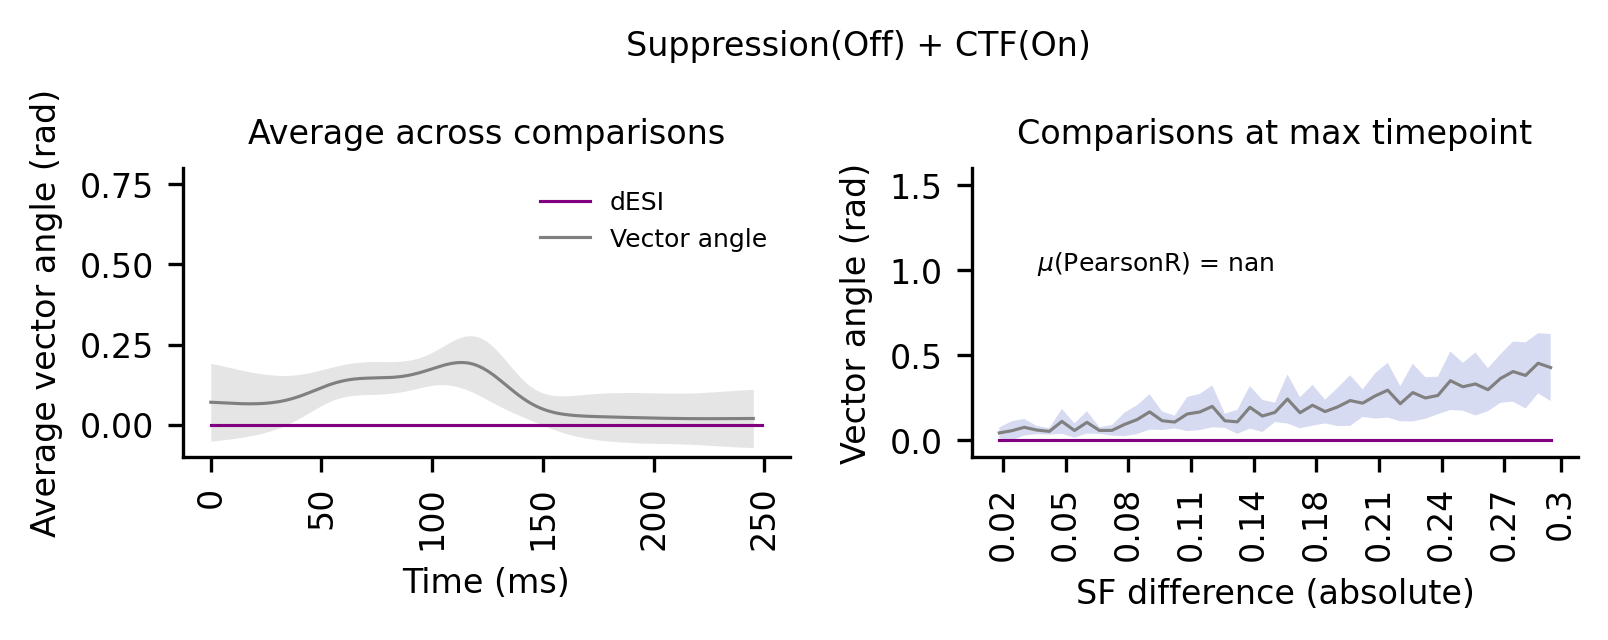

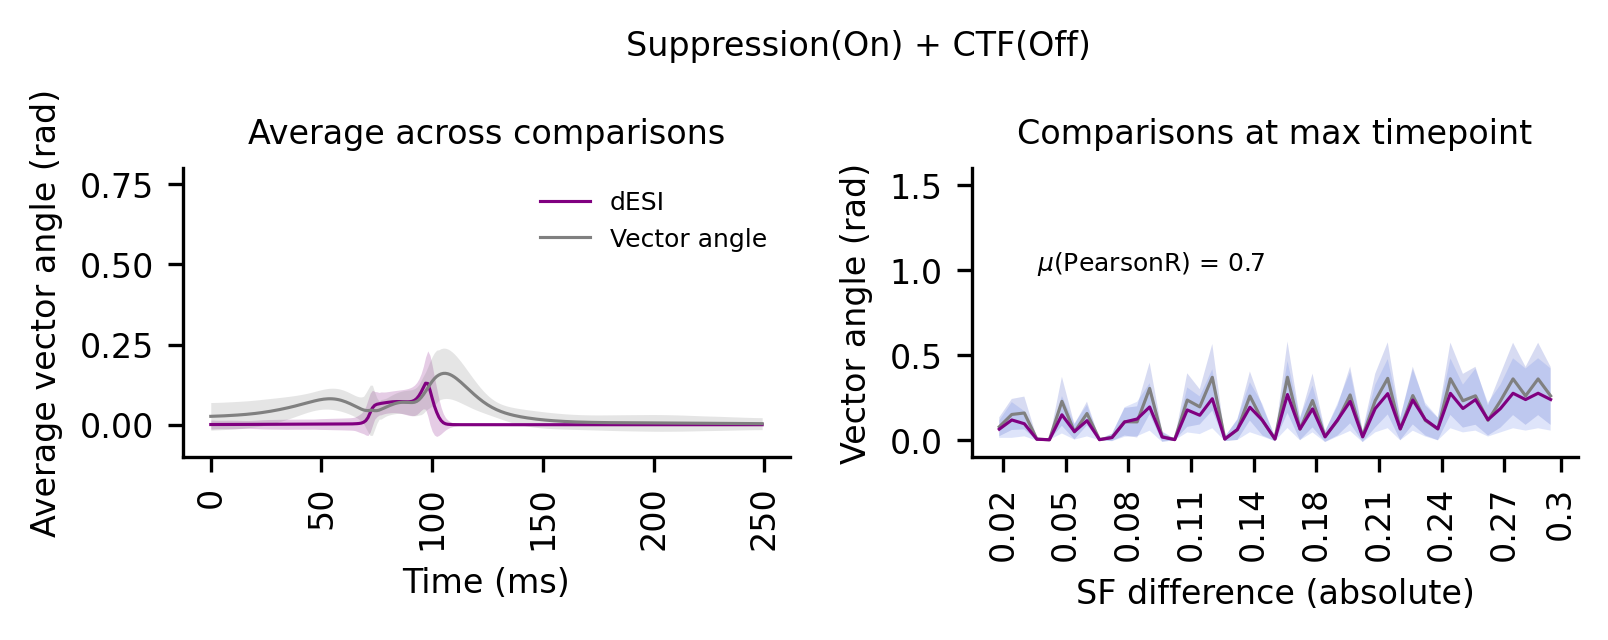

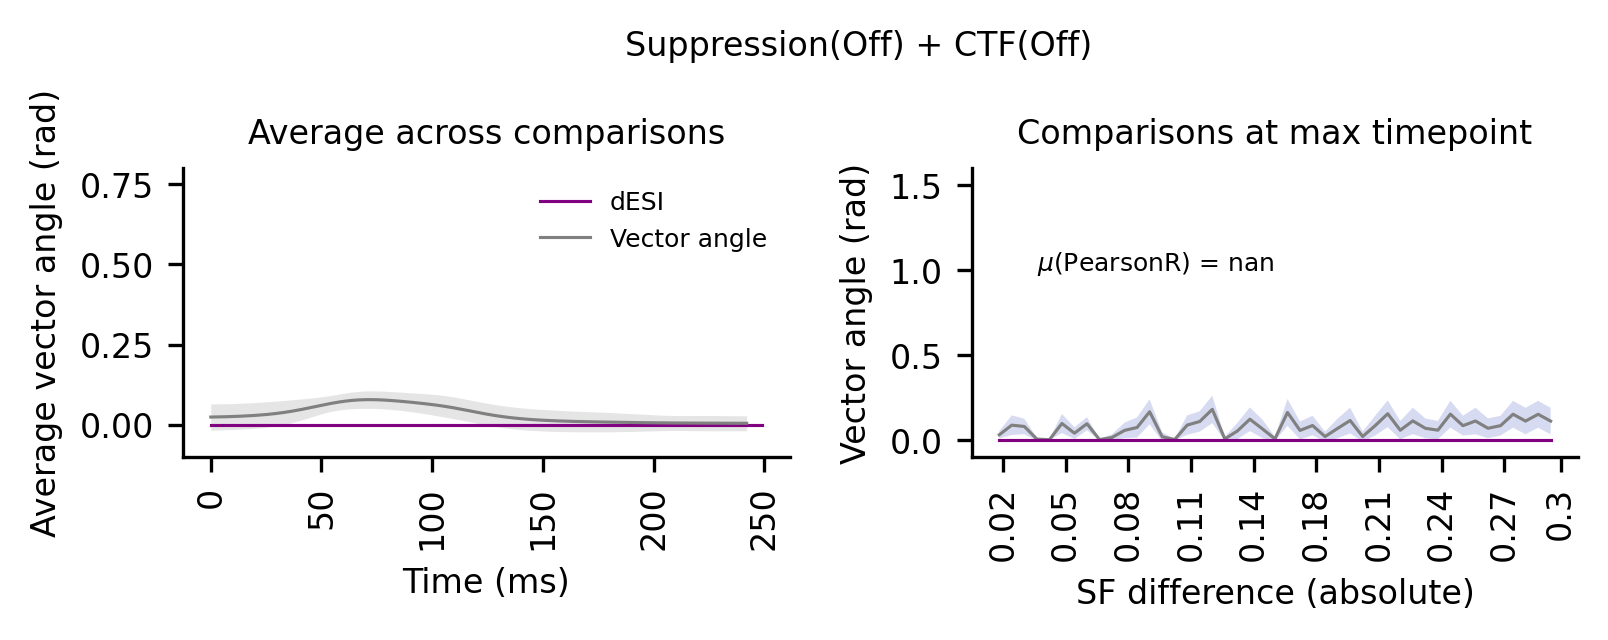

In [ ]:
for cond in data:
    cond_label = cond['cond']
    ang, dotprod, desi = cond['ang'], np.squeeze(cond['dp']), cond['desi']
    t0 = np.where(dotprod.mean((0,1))[50:] == dotprod.mean((0,1))[50:].max())[0][0] + 50
    t1 = np.where(np.nanmean(ang, (0,1))[t0:] == np.nanmean(ang, (0,1))[t0:].max())[0][0] + t0

    linewidth = 0.75
    fig, ax = plt.subplots(1,2, figsize = (6,1.25))
    ax[0].plot(desi.mean((0,1)), color = 'purple', label = 'dESI', linewidth = linewidth)
    ax[0].fill_between(
        np.arange(250),
        desi.mean((0,1)) + desi.mean(1).std(0), 
        desi.mean((0,1)) - desi.mean(1).std(0),
        desi.mean((0,1)),
        color = 'purple',
        alpha = 0.2,
        linewidth = 0
    )

    ax[0].plot(ang.mean((0,1)), color = 'gray', label = 'Vector angle', linewidth = linewidth)
    ax[0].fill_between(
        np.arange(250),
        ang.mean((0,1)) + ang.mean(1).std(0), 
        ang.mean((0,1)) - ang.mean(1).std(0),
        ang.mean((0,1)),
        color = 'gray',
        alpha = 0.2,
        linewidth = 0
    )

    ax[0].set_xlabel("Time (ms)", fontsize = fontsize)
    ax[0].set_title("Average across comparisons", fontsize = fontsize)
    ax[0].set_xticks(np.arange(0,300,50))
    ax[0].set_xticklabels(np.arange(0,300,50), rotation = 90)
    dmax = np.where(desi.mean((0,1)) == desi.mean((0,1)).max())[0][0]

    pr = np.round(np.nanmean([pearsonr(np.squeeze(desi[n,:,dmax]), ang[n,:,t1])[0] for n in range(4000)]), 2)
    ax[1].text(3, 1, f"$\mu$(PearsonR) = {pr}", fontsize = 6)
    ax[1].plot(ang.mean(0)[:,t1], '-', color = 'gray', linewidth = linewidth)
    ax[1].fill_between(
        np.arange(45),
        ang.mean(0)[:,t1] + ang.std(0)[:,t1],
        ang.mean(0)[:,t1] - ang.std(0)[:,t1],
        ang.mean(0)[:,t1],
        'gray', alpha = 0.2
    )

    ax[1].plot(desi.mean(0)[:,dmax], '-', color = 'purple', linewidth = linewidth)
    ax[1].fill_between(
        np.arange(45),
        np.squeeze(desi.mean(0)[:,dmax] + desi.std(0)[:,dmax]),
        np.squeeze(desi.mean(0)[:,dmax] - desi.std(0)[:,dmax]),
        np.squeeze(desi.mean(0)[:,dmax]),
        'purple', alpha = 0.2
    )

    ax[1].set_xticks(np.arange(0,50,5))
    ax[1].set_xlabel("SF difference (absolute)", fontsize = fontsize)
    ax[1].set_title("Comparisons at max timepoint", fontsize = fontsize)
    ticks = np.arange(0.3,45.5,5)
    ticks[-1]-=0.5
    ax[1].set_xticks(ticks)
    ax[1].set_xticklabels(np.linspace(labels[0], labels[-1], 10).round(2), rotation = 90)

    ylabels = ['Average vector angle (rad)', 'Vector angle (rad)']
    upperlims = [0.8, 1.6]
    for i in range(2):
        ax[i].tick_params(labelsize = fontsize)
        ax[i].spines['top'].set_visible(False)
        ax[i].spines['right'].set_visible(False)
        ax[i].set_ylabel(ylabels[i], fontsize = fontsize)
        ax[i].set_ylim(-0.1,upperlims[i])

    fig.subplots_adjust(wspace=0.3)
    fig.suptitle(cond_label, fontsize = 8, y = 1.25)
    ax[0].legend(fontsize = 6, loc = 'upper right', frameon=False)

    # figname = f'ablation_analysis_angsep_v_dESI_avg_&_max_{cond_label}.svg'
    # savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
    # plt.savefig(savepath, transparent = False, facecolor = 'white',
    #         bbox_inches = 'tight', dpi = 300)

C:\Users\Sturdy\AppData\Local\Temp\ipykernel_14008\2025376906.py:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[row,col].scatter(desi.mean(0)[j, dmax], ang.mean(0)[j,t1], c=cmap(c_index[c]), s=10)


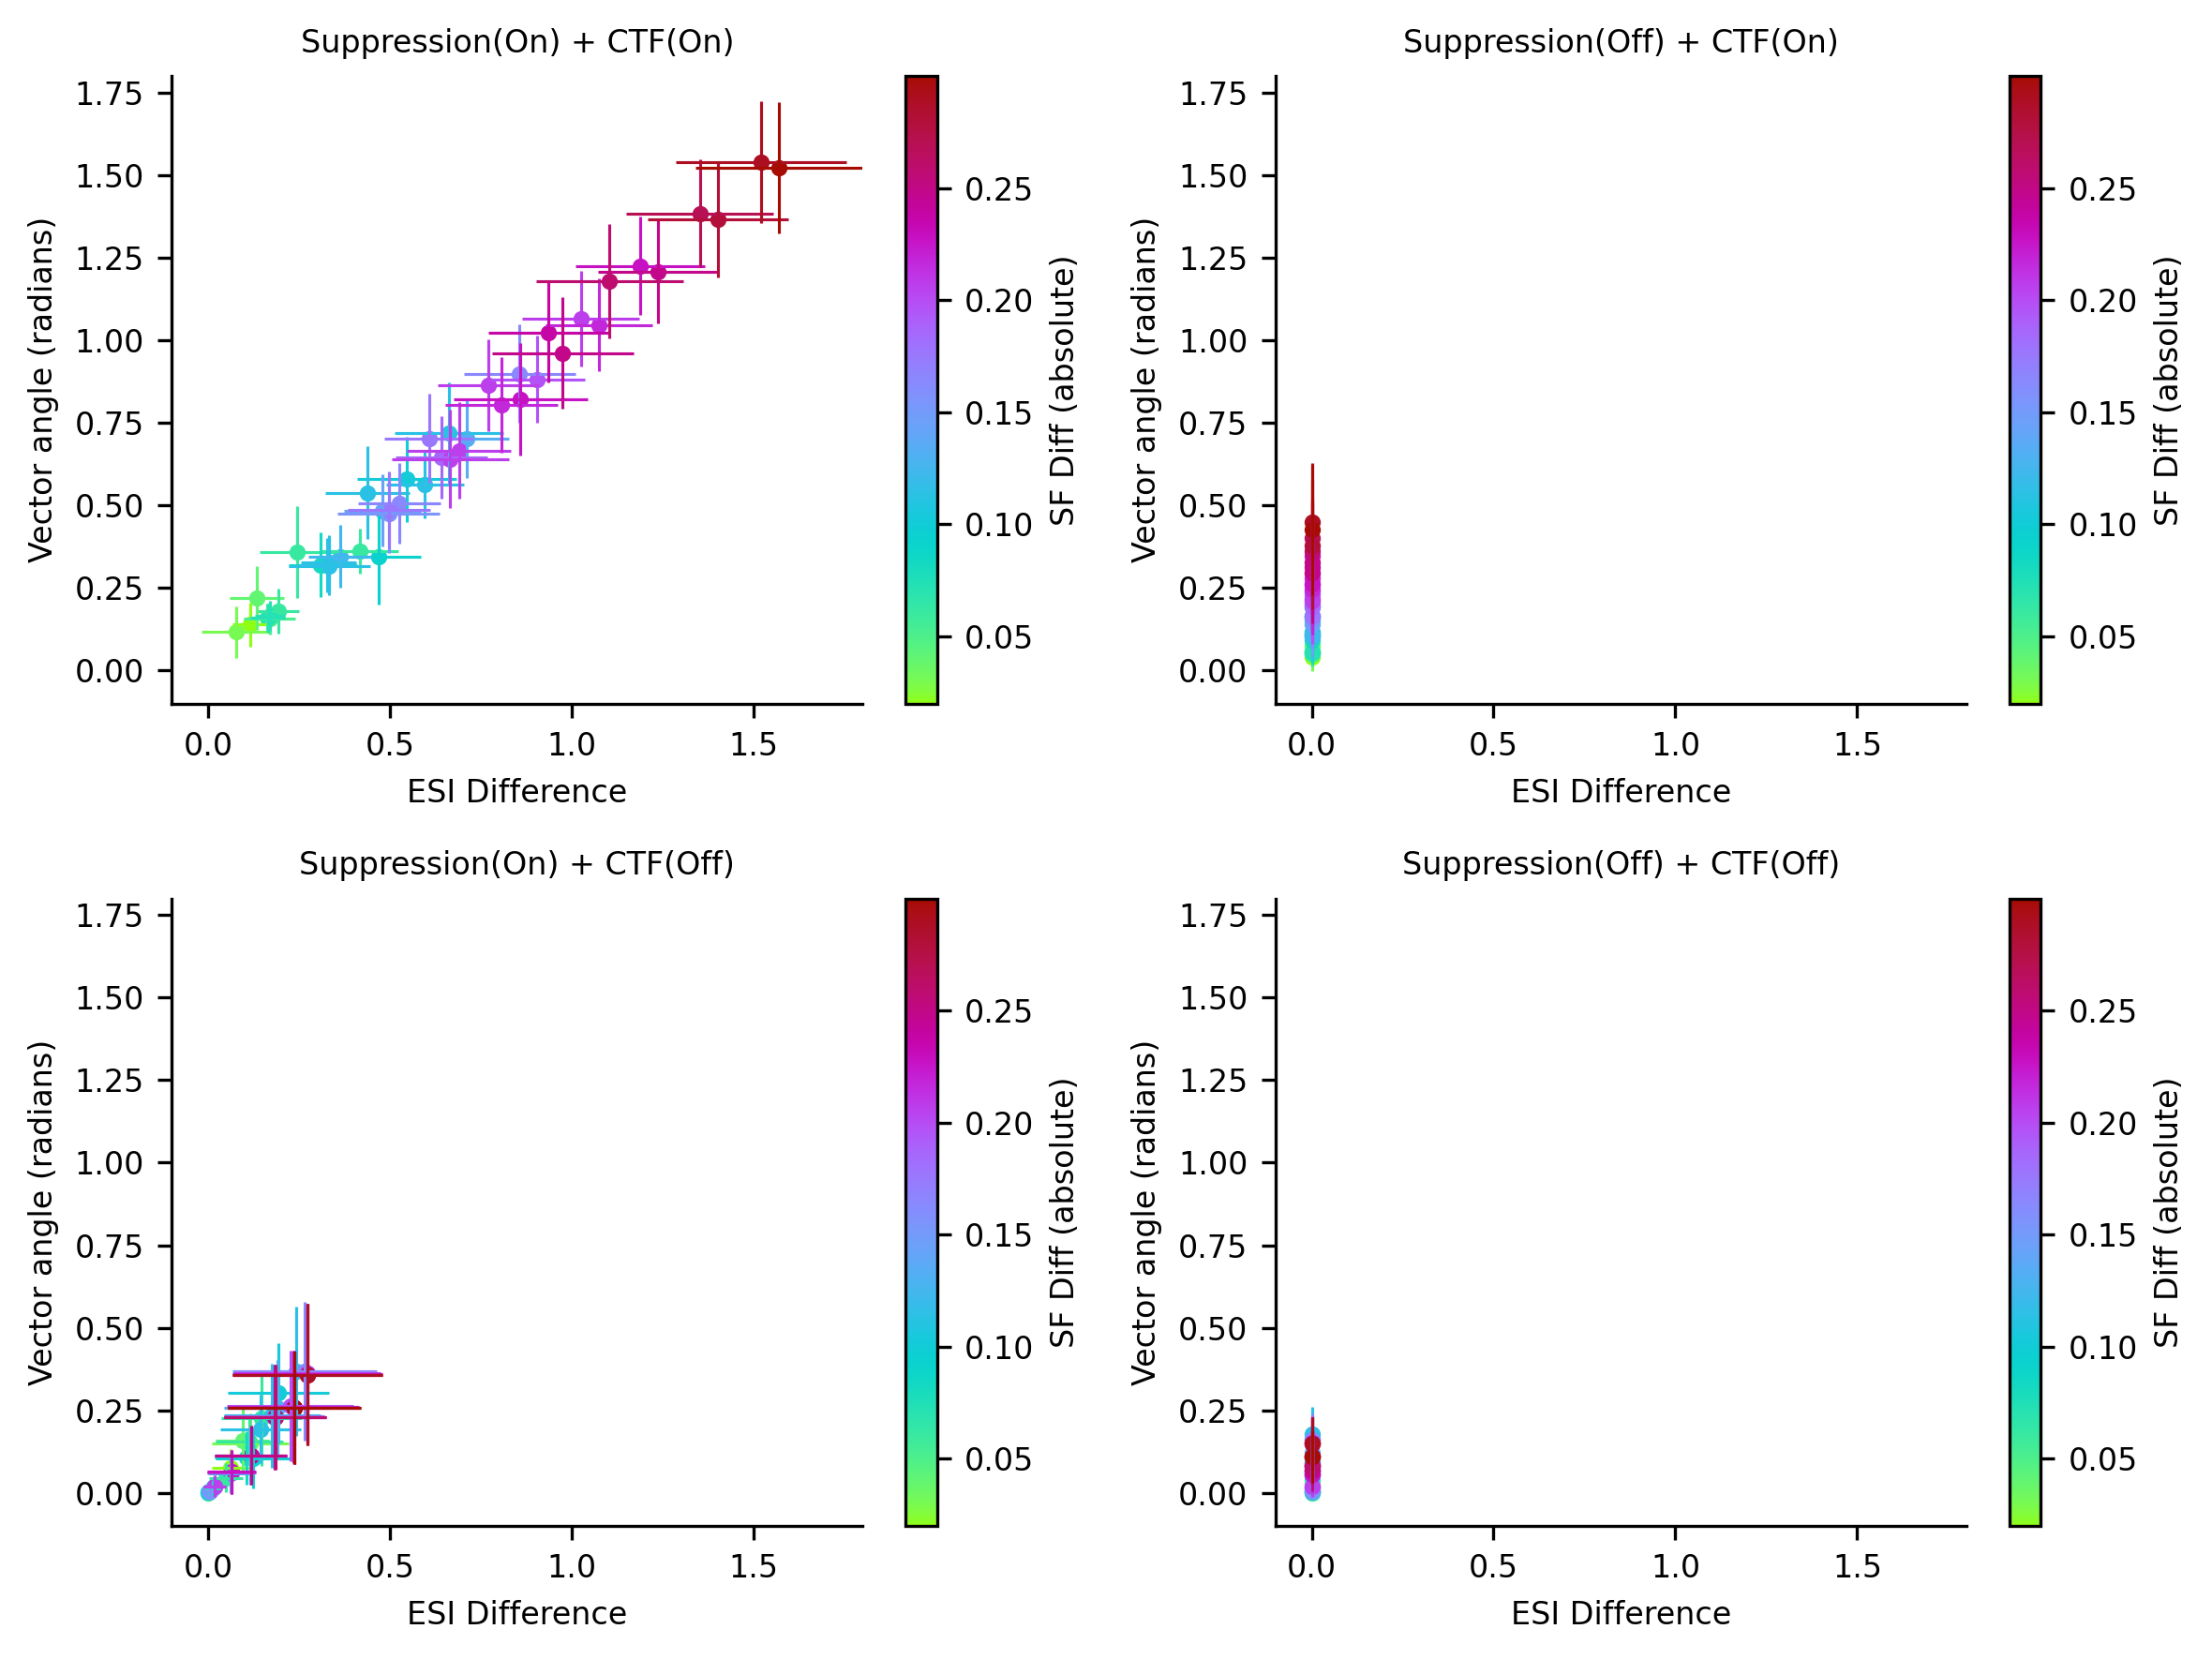

In [ ]:
fig, ax = plt.subplots(2,2, figsize = (8,6))

panel_idx = 0

for row in range(2):
    for col in range(2):
        cond = data[panel_idx]
        cond_label = cond['cond']
        order_label = cond['orderlabel']
        ang, desi = cond['ang'], cond['desi']
        t0 = np.where(dotprod.mean((0,1))[50:] == dotprod.mean((0,1))[50:].max())[0][0] + 50
        t1 = np.where(np.nanmean(ang, (0,1))[t0:] == np.nanmean(ang, (0,1))[t0:].max())[0][0] + t0
        dmax = np.where(desi.mean((0,1)) == desi.mean((0,1)).max())[0][0]

        sf_diff_unique = sorted(np.unique(order_label))
        scales = np.linspace(min(sf_diff_unique), max(sf_diff_unique), 6).round(2)
        norm = plt.Normalize(min(sf_diff_unique), max(sf_diff_unique))
        cmap = plt.get_cmap('cmr.neon_r')
        c_index = np.linspace(0, 1, 28)

        for j, diff in enumerate(order_label):
            c = sf_diff_unique.index(diff) 
            ax[row,col].scatter(desi.mean(0)[j, dmax], ang.mean(0)[j,t1], c=cmap(c_index[c]), s=10)
            ax[row,col].errorbar(
                desi.mean(0)[j, dmax], 
                ang.mean(0)[j,t1], 
                yerr=ang.std(0)[j,t1], 
                c=cmap(c_index[c]),
                elinewidth = 0.75,
            )
            ax[row,col].errorbar(
                desi.mean(0)[j, dmax], 
                ang.mean(0)[j,t1], 
                xerr=desi.std(0)[j, dmax], 
                c=cmap(c_index[c]),
                elinewidth = 0.75,
            )

        ax[row,col].spines['top'].set_visible(False)
        ax[row,col].spines['right'].set_visible(False)
        ax[row,col].tick_params(labelsize=fontsize)
        ax[row,col].set_xlabel("ESI Difference", fontsize=fontsize)
        ax[row,col].set_ylabel("Vector angle (radians)", fontsize=fontsize)
        ax[row, col].set_title(cond_label, fontsize = 8)
        ax[row, col].set_ylim(-0.1,1.8)
        ax[row, col].set_xlim(-0.1,1.8)

        sm = ScalarMappable(norm=norm, cmap=cmap)
        cbar = fig.colorbar(sm, ax=ax[row,col])
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_label("SF Diff (absolute)", fontsize=fontsize)

        panel_idx += 1 

plt.tight_layout()
# figname = f'ablation_analysis_angle_v_dESI_v_SFdiff_gayplots.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#         bbox_inches = 'tight', dpi = 300)